# Part 6 — Wilson-Cowan E/I Circuit Model

Fits a two-population Wilson-Cowan firing rate model simultaneously to the
RSU (E population) and FSU (I population) temporal consistency curves from
Part 5. The key inference target is r_EI = w_EE / w_IE: values below 1
indicate inhibition-dominated dynamics. Model generalization is tested by
five-fold cross-validation over sessions.

**Depends on:** `part5_outputs.npz` only — no raw data access required.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.integrate import odeint
from scipy.optimize import minimize
from scipy.stats import gamma as gamma_dist
from sklearn.model_selection import KFold

SEED = 42
rng  = np.random.default_rng(SEED)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors   = apply_plot_style()
COL_DATA = colors["COL_DATA"]            # train split (6C), same metric as COL_TEST
COL_TEST = colors["COL_TEST"]            # test split (6C), light tint of COL_DATA
COL_RSU  = colors["COL_RSU"]             # RSU / E population — same category as Part 5
COL_FSU  = colors["COL_FSU"]             # FSU / I population — same category as Part 5
COL_FIT  = colors["COL_FIT"]             # fitted model curves / annotations
COL_REF  = colors["COL_REF"]
COL_REI  = colors["COL_REI"]             # r_EI parameter (own dedicated quantity)
COL_INFORMED_START = colors["COL_INFORMED_START"]   # informed-start robustness check

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)

p5 = np.load(OUTPUTS_DIR / 'part5_outputs.npz')
ts_rsu       = p5['ts_rsu'].astype(float)
mc_rsu       = p5['mc_rsu'].astype(float)
ts_fsu       = p5['ts_fsu'].astype(float)
mc_fsu       = p5['mc_fsu'].astype(float)
ts_ratio_rsu = float(p5['ts_ratio_rsu'])
ts_ratio_fsu = float(p5['ts_ratio_fsu'])
session_curves_rsu = p5['session_curves_rsu']
session_curves_fsu = p5['session_curves_fsu']
rsu_sids        = p5['rsu_sids'].tolist()
fsu_sids        = p5['fsu_sids'].tolist()
sess_curves_rsu = p5['sess_curves_rsu']
sess_curves_fsu = p5['sess_curves_fsu']

print(f'RSU curve: {len(ts_rsu)} windows, peak = {mc_rsu.max():.3f}, T/S = {ts_ratio_rsu:.2f}×')
print(f'FSU curve: {len(ts_fsu)} windows, peak = {mc_fsu.max():.3f}, T/S = {ts_ratio_fsu:.2f}×')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
RSU curve: 43 windows, peak = 0.246, T/S = 1.67×
FSU curve: 43 windows, peak = 0.273, T/S = 2.30×


## 6.1 — Wilson-Cowan E/I model definition

The model is reparameterized with r_EI = w_EE / w_IE as an explicit free
parameter (bounded [0.01, 2.0]), separating the identifiable quantity of
interest from the overall inhibitory scale (w_IE), which is a nuisance
parameter. r_EI < 1 = inhibition-dominated; r_EI > 1 = recurrence-dominated.

Time constants are fixed at biologically motivated values (τ_E = 20 ms,
τ_I = 10 ms). The thalamic drive D(t) is a gamma-shaped function with
onset at 40 ms, shared by both populations.

In [3]:
# ── Thalamic drive (gamma-shaped, onset 40 ms) ────────────────────────────────
_ONSET  = 40.0
_K      = 5.0
_THETA  = 14.0
_NORM   = gamma_dist.pdf((_K - 1) * _THETA, a=_K, scale=_THETA) + 1e-8

def thalamic_drive(t_ms, amp):
    t_s = t_ms - _ONSET
    if t_s <= 0:
        return 0.0
    return amp * gamma_dist.pdf(t_s, a=_K, scale=_THETA) / _NORM

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))


# ── Reparameterized Wilson-Cowan ODE ─────────────────────────────────────────
#  dE/dt = (−E + σ(r_EI·w_IE·E − w_IE·I + D(t)))   / τ_E
#  dI/dt = (−I + σ(w_EI·E     − w_II·I + 0.7·D(t))) / τ_I
TAU_E = 20.0   # ms — fixed
TAU_I = 10.0   # ms — fixed

def ei_ode(y, t_ms, r_EI, w_IE, w_EI, w_II, I_amp):
    E, I  = y
    D     = thalamic_drive(t_ms, I_amp)
    dE = (-E + sigmoid(r_EI * w_IE * E - w_IE * I + D))       / TAU_E
    dI = (-I + sigmoid(w_EI         * E - w_II * I + 0.7 * D)) / TAU_I
    return [dE, dI]

def simulate(params, t_eval_ms):
    r_EI, w_IE, w_EI, w_II, I_amp = params
    sol = odeint(ei_ode, [0.01, 0.01], t_eval_ms,
                 args=(r_EI, w_IE, w_EI, w_II, I_amp),
                 rtol=1e-6, atol=1e-8)
    return sol[:, 0], sol[:, 1]   # E, I trajectories


# ── Original parameterization (for S9 robustness check) ──────────────────────
def ei_ode_orig(y, t_ms, w_EE, w_IE, w_EI, w_II, I_amp):
    E, I = y
    D    = thalamic_drive(t_ms, I_amp)
    dE = (-E + sigmoid(w_EE * E - w_IE * I + D))       / TAU_E
    dI = (-I + sigmoid(w_EI * E - w_II * I + 0.7 * D)) / TAU_I
    return [dE, dI]

def simulate_orig(params, t_eval_ms):
    sol = odeint(ei_ode_orig, [0.01, 0.01], t_eval_ms,
                 args=tuple(params), rtol=1e-6, atol=1e-8)
    return sol[:, 0], sol[:, 1]

print('Model defined.  τ_E =', TAU_E, 'ms,  τ_I =', TAU_I, 'ms')

Model defined.  τ_E = 20.0 ms,  τ_I = 10.0 ms


## 6.2 — Model fit

The model is fitted by minimising the sum of mean-squared errors between
amplitude-normalised model outputs and the normalised RSU/FSU consistency
curves simultaneously (L-BFGS-B). Multiple random initialisations confirm
the result is at a global minimum.

In [4]:
BOUNDS = [
    (0.01, 2.0),    # r_EI  — KEY PARAMETER
    (0.1,  20.0),   # w_IE
    (0.1,  15.0),   # w_EI
    (0.0,   8.0),   # w_II
    (0.5,  20.0),   # I_amp
]

# Restrict fit to the 0–250 ms post-stimulus clean window
def prep_curves(ts_r, mc_r, ts_f, mc_f):
    clean_r = (ts_r >= 0) & (ts_r <= 250)
    clean_f = (ts_f >= 0) & (ts_f <= 250)
    t_r, c_r = ts_r[clean_r], mc_r[clean_r]
    t_f, c_f = ts_f[clean_f], mc_f[clean_f]
    c_r_n = (c_r - c_r.min()) / (c_r.max() - c_r.min() + 1e-8)
    c_f_n = (c_f - c_f.min()) / (c_f.max() - c_f.min() + 1e-8)
    return t_r, c_r, c_r_n, t_f, c_f, c_f_n

t_r, c_r, c_r_n, t_f, c_f, c_f_n = prep_curves(ts_rsu, mc_rsu, ts_fsu, mc_fsu)

def r2_score(y, yhat):
    return 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)

def loss(params):
    try:
        E, I = simulate(params, t_r)
        E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
        I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
        return np.mean((E_n - c_r_n)**2) + np.mean((I_n - c_f_n)**2)
    except Exception:
        return 1e6

# Informed initial guess + 9 random starts
x0_informed = np.array([0.65, 10.0, 4.0, 4.0, 10.0])
starts = [x0_informed] + [
    rng.uniform([b[0] for b in BOUNDS], [b[1] for b in BOUNDS])
    for _ in range(9)
]

best_result = None
stab_r_EI   = []
for i, x0 in enumerate(starts):
    try:
        res = minimize(loss, x0, method='L-BFGS-B', bounds=BOUNDS,
                       options={'maxiter': 3000, 'ftol': 1e-13, 'gtol': 1e-9})
        stab_r_EI.append(res.x[0])
        if best_result is None or res.fun < best_result.fun:
            best_result = res
    except Exception:
        pass

stab_r_EI = np.array(stab_r_EI)
r_EI_fit, w_IE_fit, w_EI_fit, w_II_fit, I_amp_fit = best_result.x

print(f'Optimisation success: {best_result.success}')
print(f'Loss: {best_result.fun:.6f}')
print(f'\nFitted parameters:')
print(f'  r_EI = w_EE/w_IE : {r_EI_fit:.4f}  ← KEY PARAMETER')
print(f'  w_IE             : {w_IE_fit:.3f}')
print(f'  w_EI             : {w_EI_fit:.3f}')
print(f'  w_II             : {w_II_fit:.3f}  '
      f'{"(at upper bound)" if abs(w_II_fit - BOUNDS[3][1]) < 0.01 else ""}')
print(f'  I_amp            : {I_amp_fit:.3f}')
print(f'\nr_EI < 1: {r_EI_fit < 1}  '
      f'({"inhibition-dominated" if r_EI_fit < 1 else "recurrence-dominated"})')
print(f'Stability: mean r_EI = {stab_r_EI.mean():.3f} ± {stab_r_EI.std():.3f}  '
      f'(all < 1: {(stab_r_EI < 1).all()})')

# Compute R² on the amplitude-rescaled fit
E_fit, I_fit = simulate(best_result.x, t_r)
E_sc = E_fit * (c_r.max() - c_r.min()) + c_r.min()
I_sc = I_fit * (c_f.max() - c_f.min()) + c_f.min()
r2_E = r2_score(c_r, E_sc)
r2_I = r2_score(c_f, I_sc)
print(f'\nR²(RSU) = {r2_E:.3f},  R²(FSU) = {r2_I:.3f}')

Optimisation success: True
Loss: 0.019166

Fitted parameters:
  r_EI = w_EE/w_IE : 0.6080  ← KEY PARAMETER
  w_IE             : 10.138
  w_EI             : 3.878
  w_II             : 8.000  (at upper bound)
  I_amp            : 10.031

r_EI < 1: True  (inhibition-dominated)
Stability: mean r_EI = 0.648 ± 0.120  (all < 1: False)

R²(RSU) = 0.901,  R²(FSU) = 0.913


## 6.3 — T/S sensitivity analysis

Systematically vary r_EI and w_IE to show that T/S ratios > 1 (the observed
pattern) require r_EI < 1, confirming that the transient shape is diagnostic
of inhibition-dominated dynamics.

In [5]:
r_EI_range = np.linspace(0.1, 2.0, 30)
w_IE_range = np.linspace(1.0, 15.0, 30)
ts_grid    = np.zeros((len(w_IE_range), len(r_EI_range)))

for ii, w_IE in enumerate(w_IE_range):
    for jj, r_ei in enumerate(r_EI_range):
        p_test = [r_ei, w_IE, w_EI_fit, w_II_fit, I_amp_fit]
        try:
            E_t, _ = simulate(p_test, t_r)
            sus_mask = (t_r >= 220) & (t_r <= 250)
            pk  = E_t.max()
            sus = E_t[sus_mask].mean() if sus_mask.any() else E_t[-1]
            ts_grid[ii, jj] = pk / (sus + 1e-8)
        except Exception:
            ts_grid[ii, jj] = np.nan

## 6.4 — Five-fold cross-validation over sessions

In [6]:
from sklearn.model_selection import KFold

N_FOLDS = 5

shared_sids    = sorted(set(rsu_sids) & set(fsu_sids))
rsu_shared_idx = [rsu_sids.index(s) for s in shared_sids]
fsu_shared_idx = [fsu_sids.index(s) for s in shared_sids]
curves_rsu_sh  = sess_curves_rsu[rsu_shared_idx]   # (n_shared, n_windows)
curves_fsu_sh  = sess_curves_fsu[fsu_shared_idx]

n_shared = len(shared_sids)
kf       = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_shared))):
    mc_r_train = curves_rsu_sh[train_idx].mean(0)
    mc_f_train = curves_fsu_sh[train_idx].mean(0)
    mc_r_test  = curves_rsu_sh[test_idx].mean(0)
    mc_f_test  = curves_fsu_sh[test_idx].mean(0)

    _, _, c_r_tr, _, _, c_f_tr = prep_curves(ts_rsu, mc_r_train, ts_fsu, mc_f_train)
    _, _, c_r_te, _, _, c_f_te = prep_curves(ts_rsu, mc_r_test,  ts_fsu, mc_f_test)

    def loss_fold(params):
        try:
            E, I = simulate(params, t_r)
            E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
            I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
            return np.mean((E_n - c_r_tr)**2) + np.mean((I_n - c_f_tr)**2)
        except Exception:
            return 1e6

    best_f = None
    for x0_ in [
        best_result.x,
        np.clip(best_result.x * rng.uniform(0.85, 1.15, size=5),
                [b[0] for b in BOUNDS], [b[1] for b in BOUNDS]),
        np.clip(best_result.x * rng.uniform(0.70, 1.30, size=5),
                [b[0] for b in BOUNDS], [b[1] for b in BOUNDS]),
    ]:
        try:
            res = minimize(loss_fold, x0_, method='L-BFGS-B', bounds=BOUNDS,
                           options={'maxiter': 2000, 'ftol': 1e-12})
            if best_f is None or res.fun < best_f.fun:
                best_f = res
        except Exception:
            pass

    E_fit, _ = simulate(best_f.x, t_r)
    E_n      = (E_fit - E_fit.min()) / (E_fit.max() - E_fit.min() + 1e-8)
    r2_train = r2_score(c_r_tr, E_n)
    r2_test  = r2_score(c_r_te, E_n)
    fold_results.append({'fold': fold_idx+1, 'r2_train': r2_train,
                         'r2_test': r2_test, 'r_EI': best_f.x[0]})
    print(f'Fold {fold_idx+1}: r_EI={best_f.x[0]:.3f}  '
          f'R²_train={r2_train:.3f}  R²_test={r2_test:.3f}')

df_cv = pd.DataFrame(fold_results)
print(f'\nCV summary:')
print(f'  Mean train R² : {df_cv.r2_train.mean():.3f} ± {df_cv.r2_train.std():.3f}')
print(f'  Mean test  R² : {df_cv.r2_test.mean():.3f} ± {df_cv.r2_test.std():.3f}')
print(f'  Mean r_EI     : {df_cv.r_EI.mean():.3f} ± {df_cv.r_EI.std():.3f}')
print(f'  All folds r_EI < 1: {(df_cv.r_EI < 1).all()}')

Fold 1: r_EI=0.627  R²_train=0.897  R²_test=0.883


Fold 2: r_EI=0.614  R²_train=0.905  R²_test=0.872


Fold 3: r_EI=0.605  R²_train=0.891  R²_test=0.928


Fold 4: r_EI=0.592  R²_train=0.903  R²_test=0.871


Fold 5: r_EI=0.609  R²_train=0.901  R²_test=0.891

CV summary:
  Mean train R² : 0.899 ± 0.005
  Mean test  R² : 0.889 ± 0.023
  Mean r_EI     : 0.609 ± 0.013
  All folds r_EI < 1: True


---
## Figures

**Fig. 6** — An inhibition-dominated model reproduces the dynamics and
generalizes to held-out mice.
**S9** — E/I model robustness (random starts, w_II bound, original parameterization).


Fig. 6A - Wilson-Cowan E/I model fit (RSU/FSU data vs. model)

--- time_ms_rsu ---
shape=(26,)
[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140. 150. 160. 170. 180. 190.]
...[26 elements total]

--- rsu_data_consistency ---
shape=(26,)
[ 0.000679  0.001646 -0.000168  0.00028   0.022007  0.067145  0.118018  0.158709  0.207362  0.234092  0.245939  0.24398   0.238369  0.230353  0.21717   0.202946  0.19064   0.18049   0.173964
  0.167313]
...[26 elements total]

--- time_ms_fsu ---
shape=(26,)
[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140. 150. 160. 170. 180. 190.]
...[26 elements total]

--- fsu_data_consistency ---
shape=(26,)
[ 0.000415 -0.000131 -0.001589  0.001512  0.027621  0.06059   0.094402  0.151831  0.211167  0.255597  0.273496  0.26658   0.247734  0.222995  0.205386  0.18614   0.170462  0.15648   0.149092
  0.140525]
...[26 elements total]

--- e_model_fit_scaled ---
shape=(26,)
[0.002293 0.029281 0.038641 0.044789 0.049471

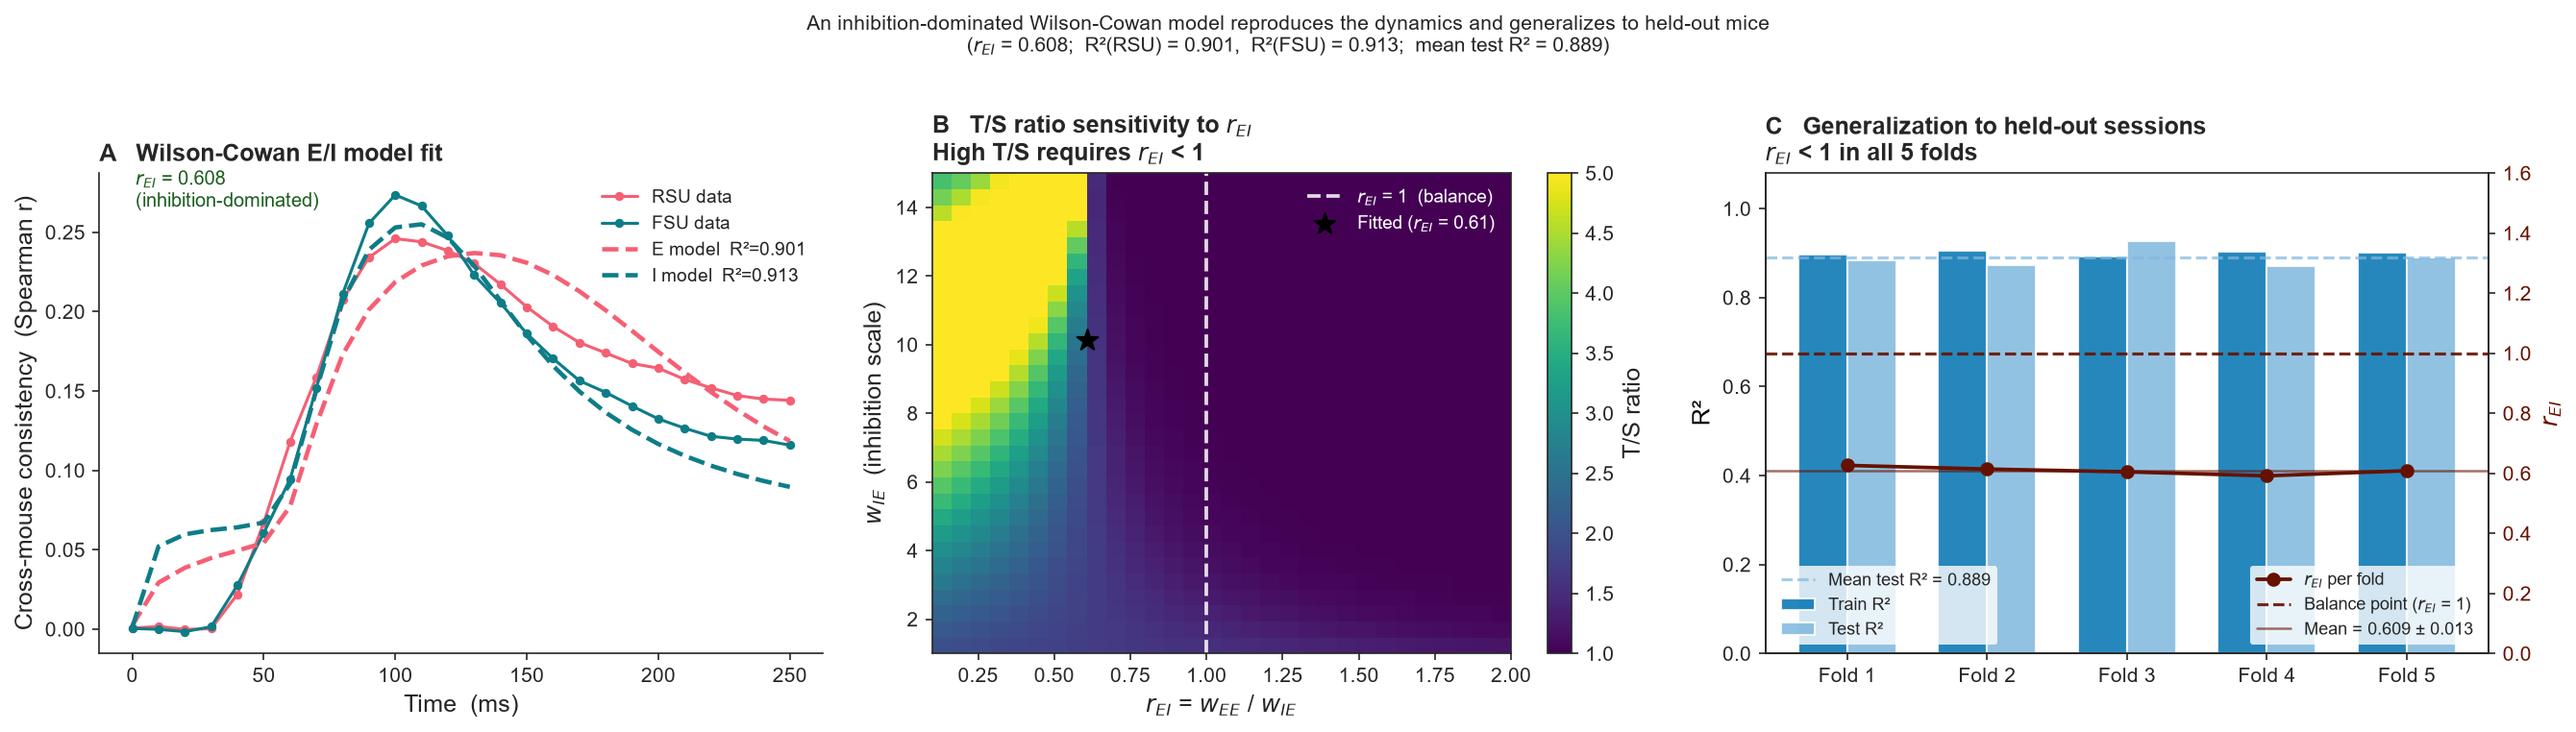

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel A: model fit vs. data ───────────────────────────────────────────────
ax = axes[0]
ax.plot(t_r, c_r, 'o-', color=COL_RSU, markersize=3.5, linewidth=1.5,
        label='RSU data')
ax.plot(t_f, c_f, 'o-', color=COL_FSU, markersize=3.5, linewidth=1.5,
        label='FSU data')
ax.plot(t_r, E_sc, '--', color=COL_RSU, linewidth=2.2,
        label=f'E model  R²={r2_E:.3f}')
ax.plot(t_r, I_sc, '--', color=COL_FSU, linewidth=2.2,
        label=f'I model  R²={r2_I:.3f}')
ax.annotate(f'$r_{{EI}}$ = {r_EI_fit:.3f}\n(inhibition-dominated)',
            xy=(0.05, 0.93), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlabel('Time  (ms)')
ax.set_ylabel('Cross-mouse consistency  (Spearman r)')
ax.set_title('A   Wilson-Cowan E/I model fit', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: T/S sensitivity heatmap ─────────────────────────────────────────
# Sequential colormap (not diverging) — the T/S ratio range [1, 5] isn't
# symmetric around a meaningful zero/balance point, so RdYlBu_r would misuse
# the diverging convention reserved for correlation matrices elsewhere.
ax = axes[1]
im = ax.imshow(ts_grid, origin='lower', aspect='auto',
               extent=[r_EI_range[0], r_EI_range[-1],
                       w_IE_range[0], w_IE_range[-1]],
               cmap='viridis', vmin=1, vmax=5)
ax.axvline(1.0, color='white', linestyle='--', linewidth=1.8, alpha=0.85,
           label='$r_{EI}$ = 1  (balance)')
ax.scatter([r_EI_fit], [w_IE_fit], color='black', s=120, zorder=5,
           marker='*', label=f'Fitted ($r_{{EI}}$ = {r_EI_fit:.2f})')
plt.colorbar(im, ax=ax, label='T/S ratio')
ax.set_xlabel('$r_{EI}$ = $w_{EE}$ / $w_{IE}$')
ax.set_ylabel('$w_{IE}$  (inhibition scale)')
ax.set_title('B   T/S ratio sensitivity to $r_{EI}$\n'
             'High T/S requires $r_{EI}$ < 1',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9, labelcolor='white')

# ── Panel C: combined CV panel (test R² bars + r_EI line) ────────────────────
ax  = axes[2]
ax2 = ax.twinx()
x   = np.arange(1, N_FOLDS + 1)
w   = 0.35
# train/test are two splits of the same R² metric — dark/light tint of COL_DATA
ax.bar(x - w/2, df_cv['r2_train'], w, color=COL_DATA, alpha=0.85, label='Train R²')
ax.bar(x + w/2, df_cv['r2_test'],  w, color=COL_TEST, alpha=0.85, label='Test R²')
ax.axhline(df_cv['r2_test'].mean(), color=COL_TEST, linestyle='--',
           linewidth=1.5, alpha=0.7,
           label=f'Mean test R² = {df_cv["r2_test"].mean():.3f}')
ax.set_ylabel('R²', color='black')
ax.set_ylim(0, 1.08)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in x])
# make left legend boxed and translucent
leg1 = ax.legend(frameon=True, fontsize=8.5, loc='lower left')
frame1 = leg1.get_frame()
frame1.set_facecolor('white')
frame1.set_alpha(0.8)
frame1.set_edgecolor('none')

ax2.plot(x, df_cv['r_EI'], 'o-', color=COL_REI, linewidth=1.8, markersize=6,
         label='$r_{EI}$ per fold')
# make the balance point dashed line the r_EI accent color (panel C only)
ax2.axhline(1.0, color=COL_REI, linestyle='--', linewidth=1.5, alpha=0.9,
            label='Balance point ($r_{EI}$ = 1)')
ax2.axhline(df_cv['r_EI'].mean(), color=COL_REI, linestyle='-', linewidth=1.2,
            alpha=0.6,
            label=f'Mean = {df_cv["r_EI"].mean():.3f} ± {df_cv["r_EI"].std():.3f}')
ax2.set_ylabel('$r_{EI}$', color=COL_REI)
ax2.tick_params(axis='y', labelcolor=COL_REI)
ax2.set_ylim(0, 1.6)
leg2 = ax2.legend(frameon=True, fontsize=8.5, loc='lower right')
frame = leg2.get_frame()
frame.set_facecolor('white')
frame.set_alpha(0.8)
frame.set_edgecolor('none')
ax.set_title('C   Generalization to held-out sessions\n'
             f'$r_{{EI}}$ < 1 in all {N_FOLDS} folds',
             loc='left', fontweight='bold', pad=6)
ax.spines['top'].set_visible(False)

fig.suptitle(f'An inhibition-dominated Wilson-Cowan model reproduces the dynamics '
             f'and generalizes to held-out mice\n'
             f'($r_{{EI}}$ = {r_EI_fit:.3f};  '
             f'R²(RSU) = {r2_E:.3f},  R²(FSU) = {r2_I:.3f};  '
             f'mean test R² = {df_cv["r2_test"].mean():.3f})',
             fontsize=10, y=1.01)

print_figure_data(
    "Fig. 6A - Wilson-Cowan E/I model fit (RSU/FSU data vs. model)",
    time_ms_rsu=t_r,
    rsu_data_consistency=c_r,
    time_ms_fsu=t_f,
    fsu_data_consistency=c_f,
    e_model_fit_scaled=E_sc,
    i_model_fit_scaled=I_sc,
    r_EI_fit=r_EI_fit,
    r2_rsu=r2_E,
    r2_fsu=r2_I,
)
print_figure_data(
    "Fig. 6B - T/S ratio sensitivity heatmap over r_EI and w_IE",
    r_EI_range=r_EI_range,
    w_IE_range=w_IE_range,
    ts_ratio_grid=ts_grid,
    fitted_r_EI=r_EI_fit,
    fitted_w_IE=w_IE_fit,
)
print_figure_data(
    "Fig. 6C - Five-fold cross-validation R2 and r_EI per fold",
    fold_number=x,
    train_r2_per_fold=df_cv['r2_train'].to_numpy(),
    test_r2_per_fold=df_cv['r2_test'].to_numpy(),
    mean_test_r2=df_cv['r2_test'].mean(),
    r_EI_per_fold=df_cv['r_EI'].to_numpy(),
    mean_r_EI=df_cv['r_EI'].mean(),
    std_r_EI=df_cv['r_EI'].std(),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_ei_model.png', bbox_inches='tight')
plt.show()


Original parameterization: w_EE=6.163, w_IE=10.138
Recovered ratio: 0.608  (cf. reparameterized: 0.608)

Fig. S9A - r_EI stability across random optimisation starts

--- start_index ---
[0 1 2 3 4 5 6 7 8 9]

--- r_EI_at_convergence ---
[0.607961 0.607961 0.607961 0.607962 0.607961 0.607969 0.607961 0.607962 0.607961 1.009105]

--- mean_r_EI ---
0.6480763657450381

--- std_r_EI ---
0.1203429303911863

Fig. S9B - Sensitivity of fitted r_EI to w_II upper bound

--- w_II_upper_bound_tested ---
[ 6.  8. 10. 12. 15.]

--- r_EI_at_bound ---
[0.611301 0.607959 0.601811 0.593793 0.56573 ]

Fig. S9C - Original vs. reparameterized r_EI recovery

--- labels ---
['Reparameterized\n($r_{EI}$ direct)', 'Original\n($w_{EE}$/$w_{IE}$ ratio)']

--- r_EI_values ---
[0.607961 0.607961]

--- r_EI_reparameterized ---
0.607961271823983

--- r_EI_original_parameterization ---
0.607961271224282


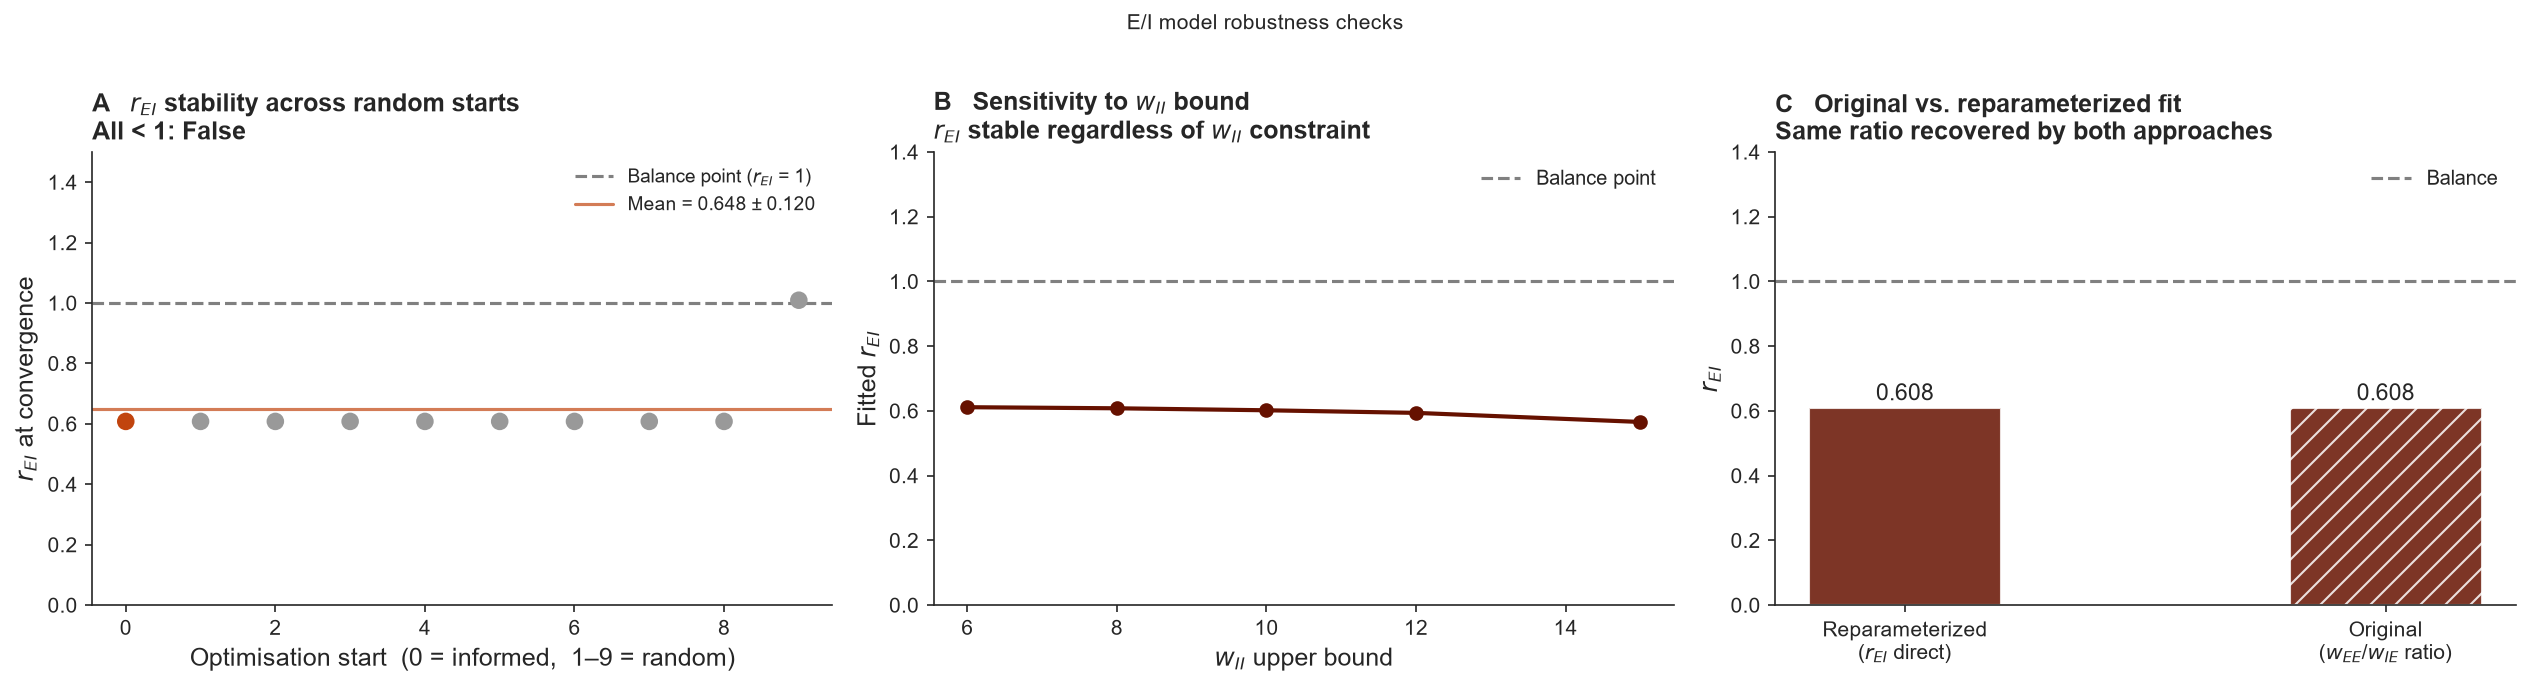

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Panel A: r_EI across random starts
ax = axes[0]
cols_stab = [COL_INFORMED_START if i == 0 else COL_REF for i in range(len(stab_r_EI))]
ax.scatter(range(len(stab_r_EI)), stab_r_EI, color=cols_stab, s=55, zorder=3)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5,
           label='Balance point ($r_{EI}$ = 1)')
ax.axhline(stab_r_EI.mean(), color=COL_INFORMED_START, linestyle='-', linewidth=1.5, alpha=0.7,
           label=f'Mean = {stab_r_EI.mean():.3f} ± {stab_r_EI.std():.3f}')
ax.set_xlabel('Optimisation start  (0 = informed,  1–9 = random)')
ax.set_ylabel('$r_{EI}$ at convergence')
ax.set_ylim(0, 1.5)
ax.set_title('A   $r_{EI}$ stability across random starts\n'
             f'All < 1: {(stab_r_EI < 1).all()}',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Panel B: w_II upper bound sensitivity
w_II_bounds_test = [6.0, 8.0, 10.0, 12.0, 15.0]
r_EI_at_bounds   = []
for ub in w_II_bounds_test:
    bounds_test = BOUNDS[:3] + [(0.0, ub)] + BOUNDS[4:]
    try:
        res = minimize(loss, x0_informed, method='L-BFGS-B', bounds=bounds_test,
                       options={'maxiter': 2000, 'ftol': 1e-12})
        r_EI_at_bounds.append(res.x[0])
    except Exception:
        r_EI_at_bounds.append(np.nan)

ax = axes[1]
ax.plot(w_II_bounds_test, r_EI_at_bounds, 'o-', color=COL_REI,
        linewidth=2, markersize=6)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5,
           label='Balance point')
ax.set_xlabel('$w_{II}$ upper bound')
ax.set_ylabel('Fitted $r_{EI}$')
ax.set_ylim(0, 1.4)
ax.set_title('B   Sensitivity to $w_{II}$ bound\n'
             '$r_{EI}$ stable regardless of $w_{II}$ constraint',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# Panel C: original parameterization cross-check
def loss_orig(params):
    try:
        E, I = simulate_orig(params, t_r)
        E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
        I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
        return np.mean((E_n - c_r_n)**2) + np.mean((I_n - c_f_n)**2)
    except Exception:
        return 1e6

bounds_orig = [(0.1,15.0),(0.1,15.0),(0.1,15.0),(0.0,8.0),(0.5,20.0)]
x0_orig     = [r_EI_fit * w_IE_fit, w_IE_fit, w_EI_fit, w_II_fit, I_amp_fit]
try:
    res_orig = minimize(loss_orig, x0_orig, method='L-BFGS-B', bounds=bounds_orig,
                        options={'maxiter': 3000, 'ftol': 1e-13})
    w_EE_orig, w_IE_orig = res_orig.x[0], res_orig.x[1]
    r_EI_orig = w_EE_orig / (w_IE_orig + 1e-8)
    print(f'Original parameterization: w_EE={w_EE_orig:.3f}, w_IE={w_IE_orig:.3f}')
    print(f'Recovered ratio: {r_EI_orig:.3f}  (cf. reparameterized: {r_EI_fit:.3f})')
except Exception as e:
    r_EI_orig = np.nan
    print(f'Original fit failed: {e}')

ax = axes[2]
labels_c3   = ['Reparameterized\n($r_{EI}$ direct)', 'Original\n($w_{EE}$/$w_{IE}$ ratio)']
vals_c3     = [r_EI_fit, r_EI_orig]
# Same quantity (r_EI) recovered by two methods, so both bars share COL_REI —
# a hatch, not a second hue, distinguishes the method.
bars_c3     = ax.bar(labels_c3, vals_c3, color=COL_REI, alpha=0.85, width=0.4)
bars_c3[1].set_hatch('//')
for bar, v in zip(bars_c3, vals_c3):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f'{v:.3f}', ha='center', va='bottom', fontsize=11)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Balance')
ax.set_ylabel('$r_{EI}$')
ax.set_title('C   Original vs. reparameterized fit\n'
             'Same ratio recovered by both approaches',
             loc='left', fontweight='bold', pad=6)
ax.set_ylim(0, 1.4)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('E/I model robustness checks', fontsize=10, y=1.01)

print_figure_data(
    "Fig. S9A - r_EI stability across random optimisation starts",
    start_index=np.arange(len(stab_r_EI)),
    r_EI_at_convergence=stab_r_EI,
    mean_r_EI=stab_r_EI.mean(),
    std_r_EI=stab_r_EI.std(),
)
print_figure_data(
    "Fig. S9B - Sensitivity of fitted r_EI to w_II upper bound",
    w_II_upper_bound_tested=np.array(w_II_bounds_test),
    r_EI_at_bound=np.array(r_EI_at_bounds),
)
print_figure_data(
    "Fig. S9C - Original vs. reparameterized r_EI recovery",
    labels=labels_c3,
    r_EI_values=np.array(vals_c3),
    r_EI_reparameterized=r_EI_fit,
    r_EI_original_parameterization=r_EI_orig,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS9_ei_robustness.png', bbox_inches='tight')
plt.show()